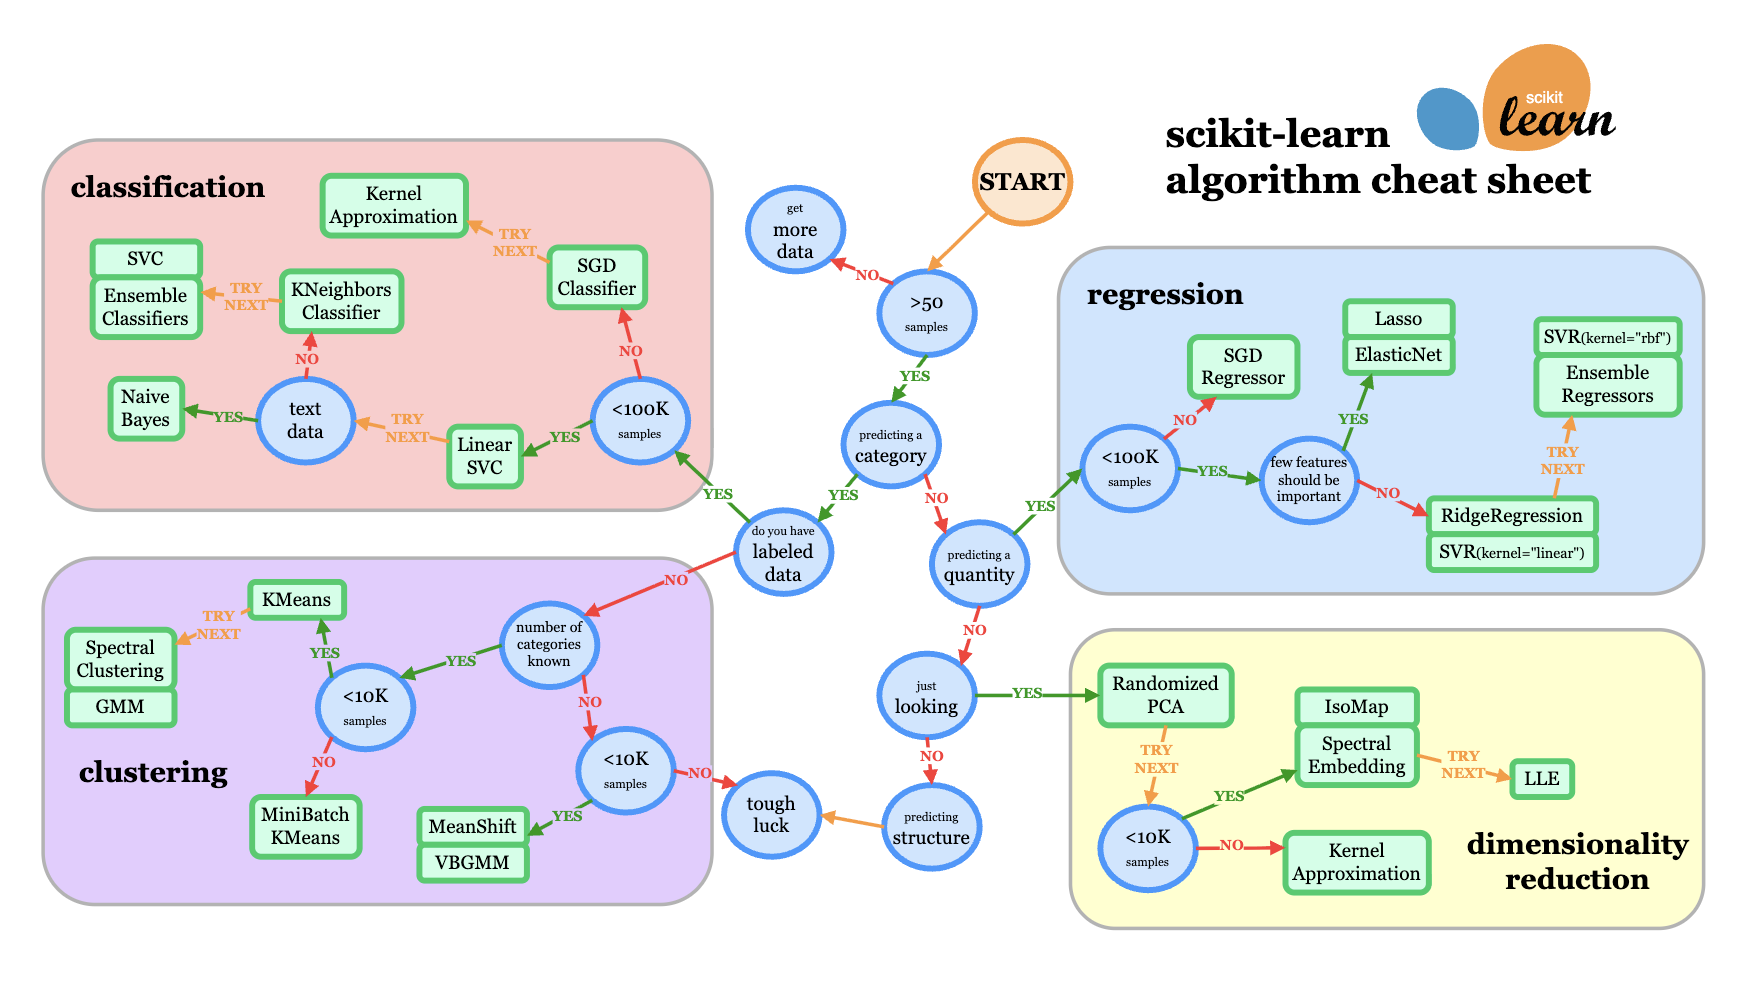

#  **The Machine Workflow**


---

#### 1. Prepare Your Data
- **Extract Features (X):** The input data for the model.
- **Extract Labels (y):** The target values or classes you want to predict.

---

#### 2. Split the Data
- Divide data into **training** and **testing** sets using  
  `train_test_split` from `model_selection`.  
  - Training data → to build the model  
  - Testing data → to check model performance  

---

#### 3. Scale the Data (if needed)
- Use `fit()` on training data to create a scaler.  
- Apply the same scaling to training and test data.

---

#### 4. Choose a Model
- Based on your task:
  - **Classification** → e.g., Logistic Regression, SVM  
  - **Regression** → e.g., Linear Regression  
  - **Clustering** → e.g., KMeans  
  - **Dimensionality Reduction** → e.g., PCA  

---

#### 5. Set Hyperparameters
- Tune settings like the number of neighbors in KNN or tree depth in decision trees.

---

#### 6. Train the Model
- Use the `fit()` method on the training data to build the model.

---

#### 7. Make Predictions or Transform Data
- **Classification/Regression** → `predict()`  
- **Dimensionality Reduction** → `transform()`  
- **Clustering** → `predict()` (assign clusters) or `transform()` (distances to clusters)

---

#### 8. Evaluate the Model
- Use `score()` or other metrics (e.g., accuracy, RMSE) on test data to measure performance.


# **Scikit-Learn Machine Learning Workflow Pipeline**
Scikit-learn is a powerful and easy-to-use machine learning library in Python.  
Here’s a simple step-by-step guide to using it effectively:

In programming, a **pipeline** is a set of procedures connected in series, one after the other, where the output of one process is the input to the next.

**Scikit-Learn** provides the `Pipeline` class to help with such sequences of transformations.



<figure>
<center>
<img src='https://drive.google.com/uc?id=1Swh0IXPb7z520Ju2ENI0h17De_iY53vk' width="550" height="250"/>
<figcaption>Machine Learning Pipeline</figcaption></center>
</figure>


## Step 0: Load the Dataset

We will use the MPG (Miles Per Gallon) dataset.
Our goal is to predict a car’s fuel efficiency based on its features.


In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [ ]:
df.shape

(398, 9)

## Step 1: Prepare the Data

- Identify input features (X)
- Identify target variable (y)
- Handle missing values
- Keep only numeric columns for simplicity


In [ ]:
# Check dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    object 
 8   name          398 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 28.1+ KB


In [ ]:
# Remove rows with missing values (simple approach for beginners)
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   model_year    392 non-null    int64  
 7   origin        392 non-null    object 
 8   name          392 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 30.6+ KB


In [ ]:
# Features (X) ["cylinders", "horsepower","weight", "acceleration"]
X = df[["cylinders", "horsepower","weight", "acceleration"]]

In [ ]:
# Target (y)
X.head()

,cylinders,horsepower,weight,acceleration
0,8,130.0,3504,12.0
1,8,165.0,3693,11.5
2,8,150.0,3436,11.0
3,8,150.0,3433,12.0
4,8,140.0,3449,10.5


In [ ]:
y = df['mpg']

In [ ]:
y

,mpg
0,18.0
1,15.0
2,18.0
3,16.0
4,17.0
...,...
393,27.0
394,44.0
395,32.0
396,28.0


## Step 2: Split the Data

We split the dataset into:
- Training set → used to train the model
- Testing set → used to evaluate performance


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_test_split()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
X_train.shape, X_test.shape

((274, 4), (118, 4))

In [ ]:
y_train.shape, y_test.shape

((274,), (118,))

## Step 3: Choose a Model

We use **Linear Regression**, one of the simplest machine learning models.
It learns a straight-line relationship between inputs and output.


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()

In [ ]:
model

LinearRegression()

## Step 4: Train the Model

The model learns patterns from the training data using `.fit()`.


In [ ]:
model.fit(X_train,y_train)

LinearRegression()

## Step 5: Make Predictions

Use the trained model to predict MPG values for the test data.


In [ ]:
X_test

,cylinders,horsepower,weight,acceleration
79,4,69.0,2189,18.0
276,4,115.0,2795,15.7
248,4,60.0,1800,16.4
56,4,70.0,1955,20.5
393,4,86.0,2790,15.6
...,...,...,...,...
80,4,86.0,2395,16.0
312,4,65.0,2019,16.4
357,4,100.0,2615,14.8
250,8,140.0,3735,13.2


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
y_pred[:10]

array([30.24882247, 24.68159749, 32.76984158, 31.24073347, 26.39016836,
       30.14075657, 10.14572566, 29.51563685, 22.58096195, 32.93744743])

In [ ]:
pd.DataFrame({"Actual MPG": y_test, "Predicted MPG": y_pred})

,Actual MPG,Predicted MPG
79,26.0,30.248822
276,21.6,24.681597
248,36.1,32.769842
56,26.0,31.240733
393,27.0,26.390168
...,...,...
80,22.0,28.331289
312,37.2,31.394271
357,32.9,26.482666
250,19.4,16.843478


## Step 6: Evaluate the Model

We use:
- R² score → how well the model explains the data
- MAE → average prediction error
- RMSE → penalizes large errors

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [ ]:
r2_score(y_test, y_pred)

0.6513932335607815

## Step 7: View the Learned Equation

A Linear Regression model learns an equation of the form:

MPG = b₀ + b₁·(cylinders) + b₂·(displacement) + b₃·(horsepower)
      + b₄·(weight) + b₅·(acceleration) + b₆·(model_year)

Where:
- b₀ is the intercept
- b₁…b₆ are learned coefficients


In [ ]:
# Display the learned coefficients
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

,Feature,Coefficient
0,cylinders,-0.459877
1,horsepower,-0.057909
2,weight,-0.004959
3,acceleration,-0.044237


In [ ]:
# New car data (must match feature order)
# Create a DataFrame with the same column names
new_car = pd.DataFrame({
    "cylinders": [4],
    "horsepower": [90],
    "weight": [2500],
    "acceleration": [15]
})
new_car

,cylinders,horsepower,weight,acceleration
0,4,90,2500,15


In [ ]:
model.predict(new_car)

array([27.62319373])